# CS465 – Student Dropout Prediction
## Phase 3: Dataset Characterization, Feature Engineering & Methodology
**Areen Al Ruwaitea – 222410547 | Layal Alsultan – 221410010**

In [28]:
# import all libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE

import xgboost as xgb

print('all libraries imported successfully')

all libraries imported successfully


---
## Section 1 – Dataset Characterization, Preprocessing & EDA

In [29]:
df = pd.read_csv('student dropout.csv')
print('Shape:', df.shape)
df.head()

Shape: (649, 34)


,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,False
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,False
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,False
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,False


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   School                       649 non-null    object
 1   Gender                       649 non-null    object
 2   Age                          649 non-null    int64 
 3   Address                      649 non-null    object
 4   Family_Size                  649 non-null    object
 5   Parental_Status              649 non-null    object
 6   Mother_Education             649 non-null    int64 
 7   Father_Education             649 non-null    int64 
 8   Mother_Job                   649 non-null    object
 9   Father_Job                   649 non-null    object
 10  Reason_for_Choosing_School   649 non-null    object
 11  Guardian                     649 non-null    object
 12  Travel_Time                  649 non-null    int64 
 13  Study_Time                   649 no

In [31]:
# check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found')

Missing values per column:
No missing values found


In [32]:
# basic statistical summary of numerical features
df.describe().round(2)

,Age,Mother_Education,Father_Education,Travel_Time,Study_Time,Number_of_Failures,Family_Relationship,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade
count,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00,649.00
mean,16.74,2.51,2.31,1.57,1.93,0.22,3.93,3.18,3.18,1.50,2.28,3.54,3.66,11.40,11.57,11.91
std,1.22,1.13,1.10,0.75,0.83,0.59,0.96,1.05,1.18,0.92,1.28,1.45,4.64,2.75,2.91,3.23
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,16.00,2.00,1.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,2.00,0.00,10.00,10.00,10.00
50%,17.00,2.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,2.00,11.00,11.00,12.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,6.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,32.00,19.00,19.00,19.00


Class Distribution:
  Not Dropped Out (0): 549  (84.6%)
  Dropped Out     (1): 100  (15.4%)


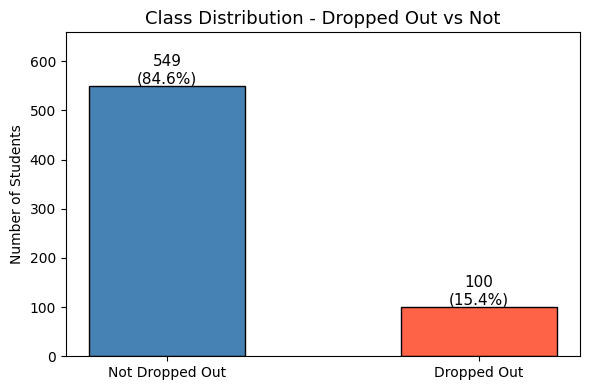

In [33]:
# check the class distribution of the target variable
df['Dropped_Out'] = df['Dropped_Out'].astype(int)

counts = df['Dropped_Out'].value_counts().sort_index()
pcts   = df['Dropped_Out'].value_counts(normalize=True).sort_index() * 100 # % of each class in dataset
print('Class Distribution:')
print(f'  Not Dropped Out (0): {counts[0]}  ({pcts[0]:.1f}%)')
print(f'  Dropped Out     (1): {counts[1]}  ({pcts[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Not Dropped Out', 'Dropped Out'], [counts[0], counts[1]],
       color=['steelblue', 'tomato'], edgecolor='black', width=0.5)

for i, (v, p) in enumerate(zip([counts[0], counts[1]], [pcts[0], pcts[1]])):
    ax.text(i, v + 5, f'{v}\n({p:.1f}%)', ha='center', fontsize=11) # to label bars

ax.set_title('Class Distribution - Dropped Out vs Not', fontsize=13)
ax.set_ylabel('Number of Students')
ax.set_ylim(0, max(counts) * 1.2) # boundary of y-axis from 0-20% taller than max bar
plt.tight_layout()
plt.show()


In [34]:
# encode all categorical columns (obj type) with label encoding
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns to encode:', cat_cols)

le = LabelEncoder() # text to no.
df_encoded = df.copy() #copy of encoded df
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df[col])

print('Encoding done. Sample:')
df_encoded.head(3)

Categorical columns to encode: ['School', 'Gender', 'Address', 'Family_Size', 'Parental_Status', 'Mother_Job', 'Father_Job', 'Reason_for_Choosing_School', 'Guardian', 'School_Support', 'Family_Support', 'Extra_Paid_Class', 'Extra_Curricular_Activities', 'Attended_Nursery', 'Wants_Higher_Education', 'Internet_Access', 'In_Relationship']
Encoding done. Sample:


,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
0,0,0,18,1,0,0,4,4,0,4,...,3,4,1,1,3,4,0,11,11,0
1,0,0,17,1,0,1,1,1,0,2,...,3,3,1,1,3,2,9,11,11,0
2,0,0,15,1,1,1,1,1,0,2,...,3,2,2,3,3,6,12,13,12,0


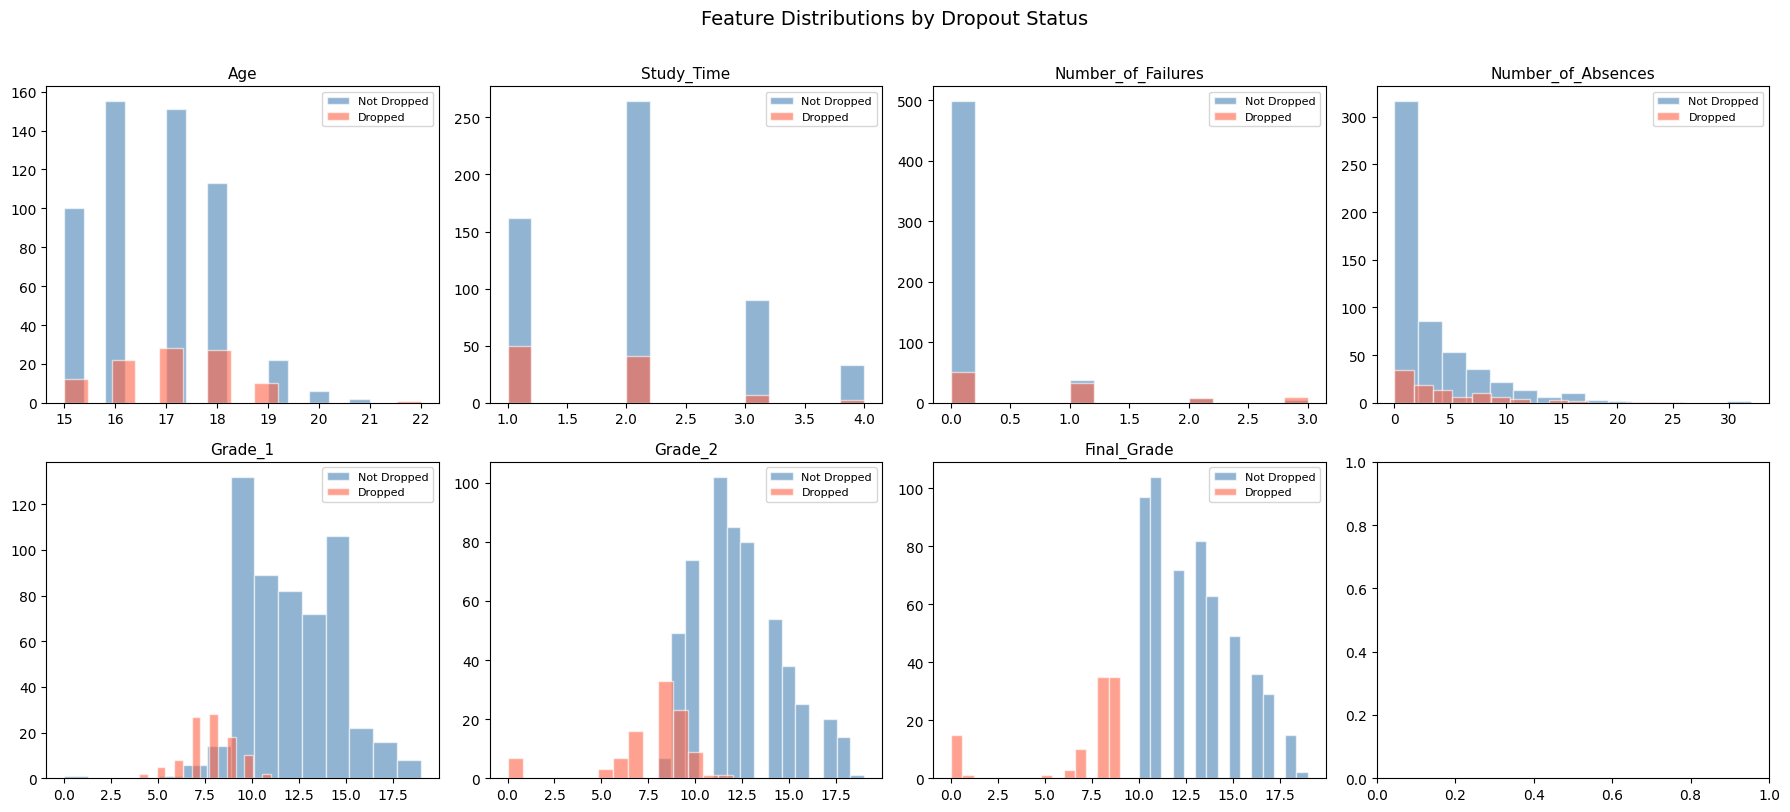

In [35]:
# plot distribution of a few key numerical features by class
num_features = ['Age', 'Study_Time', 'Number_of_Failures', 'Number_of_Absences',
                'Grade_1', 'Grade_2', 'Final_Grade']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    for label, color, name in [(0, 'steelblue', 'Not Dropped'), (1, 'tomato', 'Dropped')]:
        axes[i].hist(df[df['Dropped_Out'] == label][feat].dropna(),
                     alpha=0.6, color=color, label=name, bins=15, edgecolor='white')
    axes[i].set_title(feat, fontsize=11)
    axes[i].legend(fontsize=8)


fig.suptitle('Feature Distributions by Dropout Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

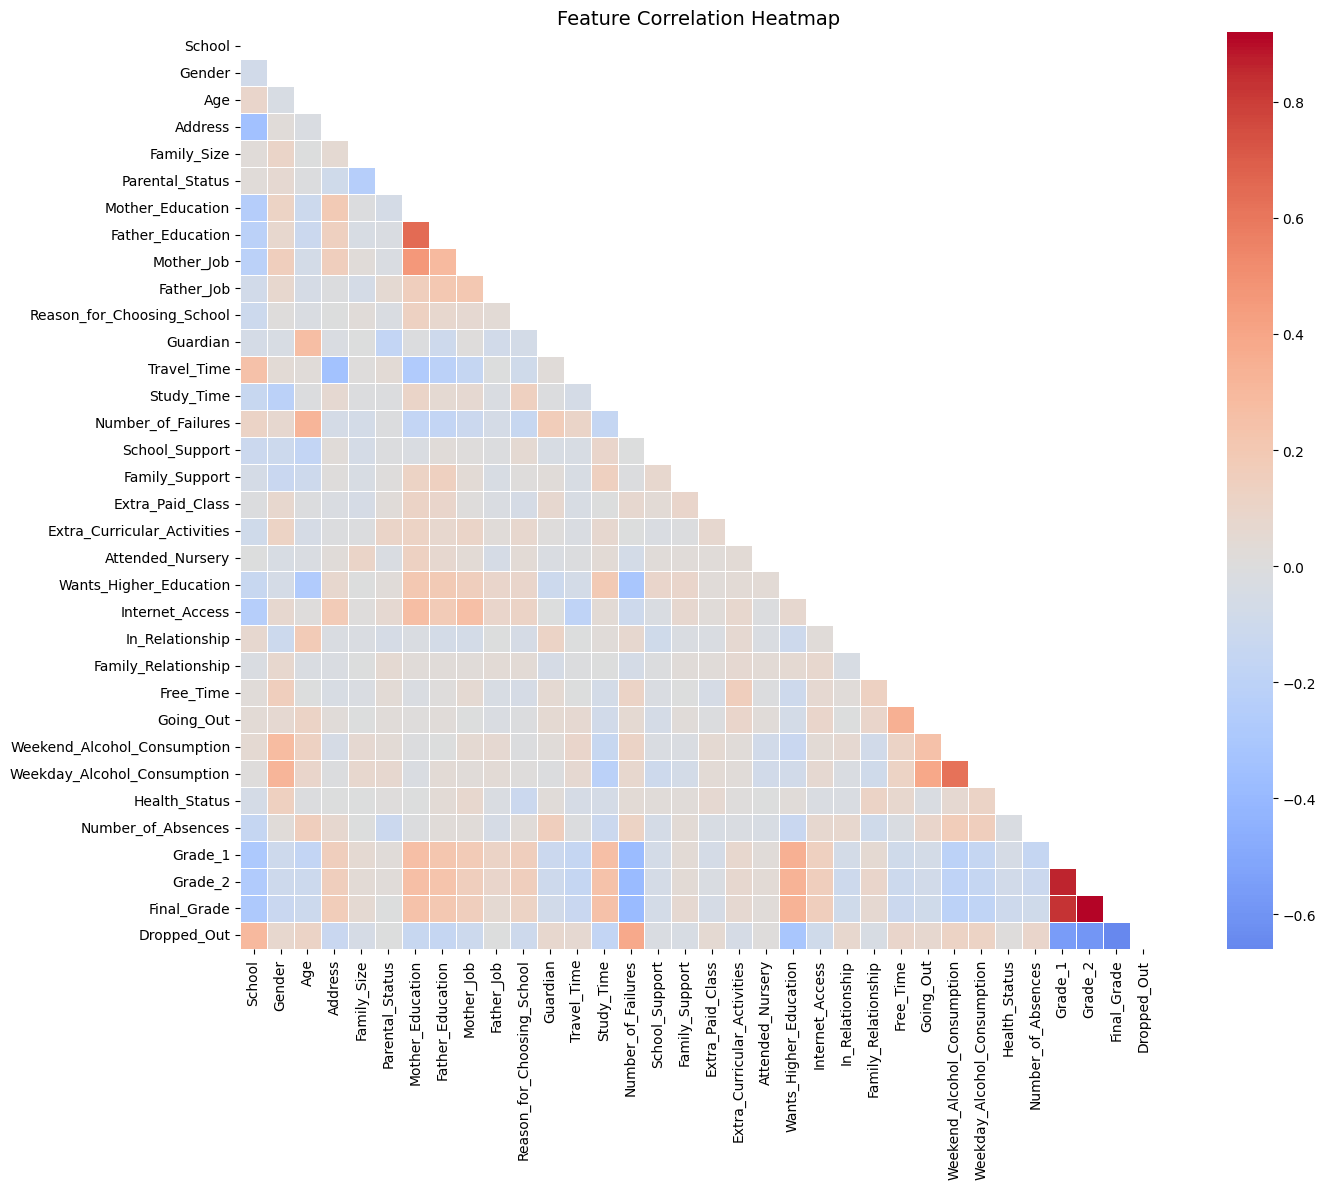

In [36]:
# correlation heatmap to see which features relate to each other
plt.figure(figsize=(16, 12))
corr = df_encoded.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.4, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

Top 10 features correlated with Dropped_Out:
Final_Grade              -0.663
Grade_2                  -0.592
Grade_1                  -0.563
Number_of_Failures        0.380
Wants_Higher_Education   -0.310
School                    0.297
Study_Time               -0.165
Father_Education         -0.146
Mother_Education         -0.145
Address                  -0.127
Name: Dropped_Out, dtype: float64


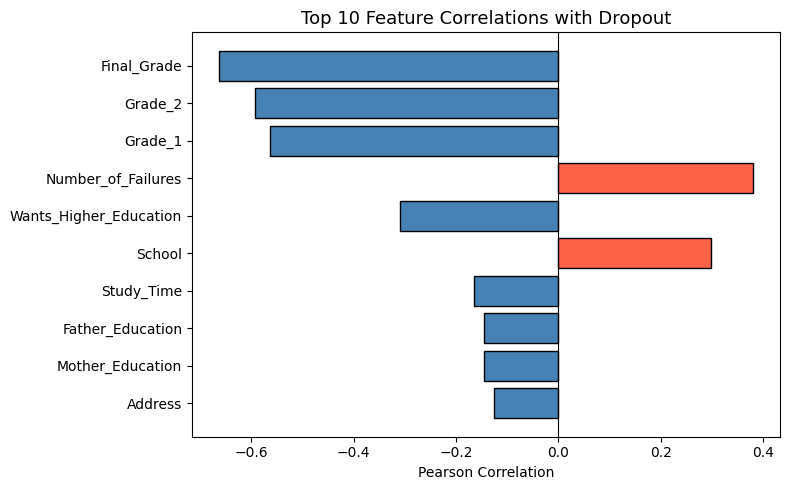

In [37]:
# top correlations with the target variable specifically
target_corr = df_encoded.corr()['Dropped_Out'].drop('Dropped_Out').sort_values(key=abs, ascending=False)
print('Top 10 features correlated with Dropped_Out:')
print(target_corr.head(10).round(3))

fig, ax = plt.subplots(figsize=(8, 5))
top10 = target_corr.head(10)
colors = ['tomato' if v > 0 else 'steelblue' for v in top10.values]
ax.barh(top10.index[::-1], top10.values[::-1], color=colors[::-1], edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 10 Feature Correlations with Dropout', fontsize=13)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

# Red +ve correlation
# Blue -ve correlation

/tmp/ipykernel_5674/1803082376.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_0, data_1], labels=['Not Dropped', 'Dropped'],
/tmp/ipykernel_5674/1803082376.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_0, data_1], labels=['Not Dropped', 'Dropped'],
/tmp/ipykernel_5674/1803082376.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_0, data_1], labels=['Not Dropped', 'Dropped'],


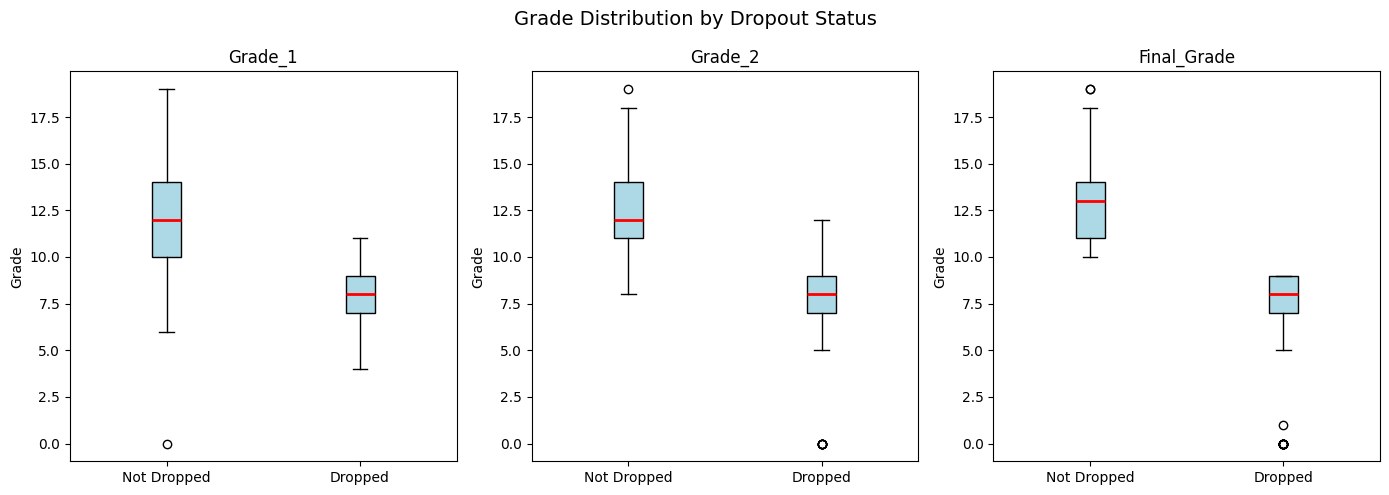

In [38]:
# box plots for grade features by dropout class
grade_cols = ['Grade_1', 'Grade_2', 'Final_Grade']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(grade_cols):
    data_0 = df[df['Dropped_Out'] == 0][col]
    data_1 = df[df['Dropped_Out'] == 1][col]
    axes[i].boxplot([data_0, data_1], labels=['Not Dropped', 'Dropped'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Grade')

fig.suptitle('Grade Distribution by Dropout Status', fontsize=14)
plt.tight_layout()
plt.show()

---
## Section 2 – Feature Engineering & Baseline Reproduction

In [39]:
# create a few engineered features based on EDA findings
df_feat = df_encoded.copy()

# average grade across all three assessments
df_feat['Avg_Grade'] = (df_feat['Grade_1'] + df_feat['Grade_2'] + df_feat['Final_Grade']) / 3

# grade improvement from grade 1 to grade 2
df_feat['Grade_Improvement'] = df_feat['Grade_2'] - df_feat['Grade_1']

# flag for students with any failures (common dropout risk indicator)
df_feat['Has_Failures'] = (df_feat['Number_of_Failures'] > 0).astype(int)

# high absence flag (above median)
median_abs = df_feat['Number_of_Absences'].median()
df_feat['High_Absences'] = (df_feat['Number_of_Absences'] > median_abs).astype(int)

print('New features added: Avg_Grade, Grade_Improvement, Has_Failures, High_Absences')
df_feat[['Avg_Grade', 'Grade_Improvement', 'Has_Failures', 'High_Absences', 'Dropped_Out']].head()

New features added: Avg_Grade, Grade_Improvement, Has_Failures, High_Absences


,Avg_Grade,Grade_Improvement,Has_Failures,High_Absences,Dropped_Out
0,7.333333,11,0,1,0
1,10.333333,2,0,0,0
2,12.333333,1,0,1,0
3,14.000000,0,0,0,0
4,12.333333,2,0,0,0


In [40]:
# separate features and target, then scale numerical columns
X = df_feat.drop('Dropped_Out', axis=1)
y = df_feat['Dropped_Out']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('Feature matrix shape:', X_scaled.shape)
print('Target distribution:', y.value_counts().to_dict())

Feature matrix shape: (649, 37)
Target distribution: {0: 549, 1: 100}


In [41]:
# stratified train/test split to keep class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set:', X_train.shape, '| Dropout rate:', round(y_train.mean()*100, 1), '%')
print('Test set:    ', X_test.shape,  '| Dropout rate:', round(y_test.mean()*100, 1), '%')

Training set: (519, 37) | Dropout rate: 15.4 %
Test set:     (130, 37) | Dropout rate: 15.4 %


In [42]:
# apply SMOTE on training data only to handle class imbalance
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print('After SMOTE:')
print('  Training set size:', X_train_sm.shape)
print('  Class distribution:', pd.Series(y_train_sm).value_counts().to_dict())

After SMOTE:
  Training set size: (878, 37)
  Class distribution: {0: 439, 1: 439}


---
## Section 3 – Methodology, Benchmarking & Experimental Evaluation

In [43]:
# define all models we want to compare (baselines + stronger models)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes':         GaussianNB(),
    'SVM':                 SVC(probability=True, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':             xgb.XGBClassifier(n_estimators=100, random_state=42,
                                              use_label_encoder=False, eval_metric='logloss')
}
print('Models defined:', list(models.keys()))

Models defined: ['Logistic Regression', 'Decision Tree', 'K-Nearest Neighbors', 'Naive Bayes', 'SVM', 'Random Forest', 'Gradient Boosting', 'XGBoost']


In [44]:
# helper function to compute all our benchmark metrics for a model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    spec  = tn / (tn + fp)
    gmean = np.sqrt(rec * spec)

    return {'Model': name, 'Accuracy': round(acc,4), 'F1-Score': round(f1,4),
            'Recall': round(rec,4), 'Precision': round(prec,4),
            'G-Mean': round(gmean,4)}

print('evaluation function ready')

evaluation function ready


In [45]:
# run all models WITHOUT SMOTE first (baseline)
results_no_smote = []
for name, model in models.items():
    r = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    results_no_smote.append(r)
    print(f'{name}: F1={r["F1-Score"]}, Recall={r["Recall"]}')

df_results_base = pd.DataFrame(results_no_smote).sort_values('F1-Score', ascending=False)
print('\nBaseline results (no SMOTE):')
df_results_base

Logistic Regression: F1=0.85, Recall=0.85
Decision Tree: F1=1.0, Recall=1.0
K-Nearest Neighbors: F1=0.6875, Recall=0.55
Naive Bayes: F1=0.7083, Recall=0.85
SVM: F1=0.7273, Recall=0.6
Random Forest: F1=0.9744, Recall=0.95
Gradient Boosting: F1=1.0, Recall=1.0
XGBoost: F1=1.0, Recall=1.0

Baseline results (no SMOTE):


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:36:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,F1-Score,Recall,Precision,G-Mean
1,Decision Tree,1.0000,1.0000,1.00,1.0000,1.0000
7,XGBoost,1.0000,1.0000,1.00,1.0000,1.0000
6,Gradient Boosting,1.0000,1.0000,1.00,1.0000,1.0000
5,Random Forest,0.9923,0.9744,0.95,1.0000,0.9747
0,Logistic Regression,0.9538,0.8500,0.85,0.8500,0.9093
4,SVM,0.9308,0.7273,0.60,0.9231,0.7711
3,Naive Bayes,0.8923,0.7083,0.85,0.6071,0.8746
2,K-Nearest Neighbors,0.9231,0.6875,0.55,0.9167,0.7382


In [46]:
# run all models WITH SMOTE
results_smote = []
for name, model in models.items():
    r = evaluate_model(name, model, X_train_sm, y_train_sm, X_test, y_test)
    results_smote.append(r)
    print(f'{name}: F1={r["F1-Score"]}, Recall={r["Recall"]}')

df_results_smote = pd.DataFrame(results_smote).sort_values('F1-Score', ascending=False)
print('\nResults with SMOTE:')
df_results_smote

Logistic Regression: F1=0.8372, Recall=0.9
Decision Tree: F1=1.0, Recall=1.0
K-Nearest Neighbors: F1=0.5902, Recall=0.9
Naive Bayes: F1=0.64, Recall=0.8
SVM: F1=0.7317, Recall=0.75
Random Forest: F1=0.9744, Recall=0.95
Gradient Boosting: F1=1.0, Recall=1.0


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:36:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: F1=1.0, Recall=1.0

Results with SMOTE:


,Model,Accuracy,F1-Score,Recall,Precision,G-Mean
1,Decision Tree,1.0000,1.0000,1.00,1.0000,1.0000
7,XGBoost,1.0000,1.0000,1.00,1.0000,1.0000
6,Gradient Boosting,1.0000,1.0000,1.00,1.0000,1.0000
5,Random Forest,0.9923,0.9744,0.95,1.0000,0.9747
0,Logistic Regression,0.9462,0.8372,0.90,0.7826,0.9269
4,SVM,0.9154,0.7317,0.75,0.7143,0.8421
3,Naive Bayes,0.8615,0.6400,0.80,0.5333,0.8356
2,K-Nearest Neighbors,0.8077,0.5902,0.90,0.4390,0.8437


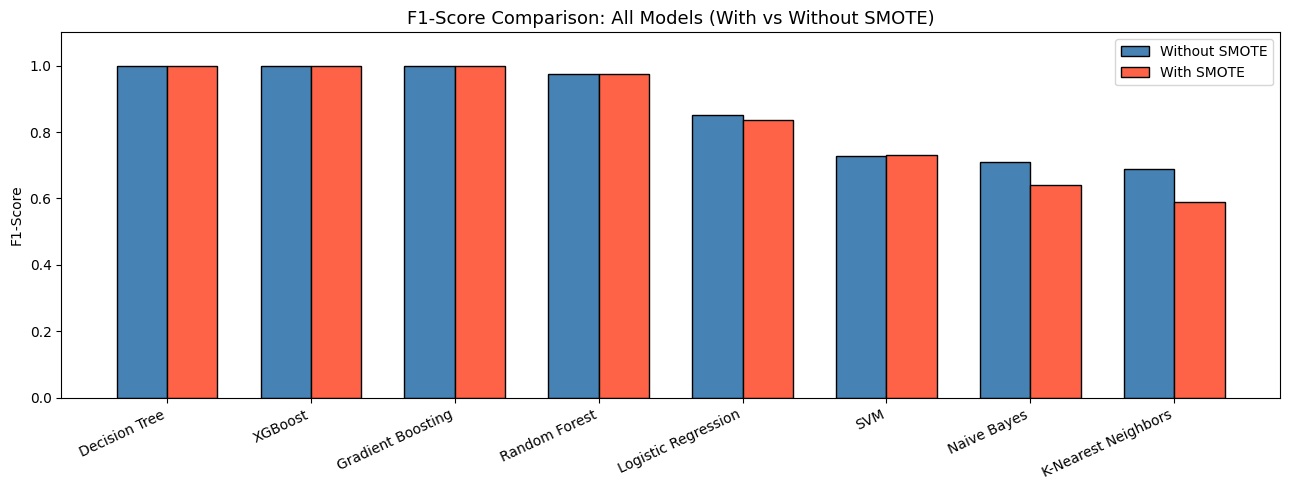

In [47]:
# bar chart comparing F1 scores across all models (with vs without SMOTE)
model_names = df_results_base['Model'].tolist()
f1_base  = df_results_base.set_index('Model').loc[model_names, 'F1-Score'].values
f1_smote = df_results_smote.set_index('Model').loc[model_names, 'F1-Score'].values

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, f1_base,  width, label='Without SMOTE', color='steelblue', edgecolor='black')
ax.bar(x + width/2, f1_smote, width, label='With SMOTE',    color='tomato',    edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.1)
ax.set_title('F1-Score Comparison: All Models (With vs Without SMOTE)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

Best model: Decision Tree
              precision    recall  f1-score   support

 Not Dropped       1.00      1.00      1.00       110
     Dropped       1.00      1.00      1.00        20

    accuracy                           1.00       130
   macro avg       1.00      1.00      1.00       130
weighted avg       1.00      1.00      1.00       130



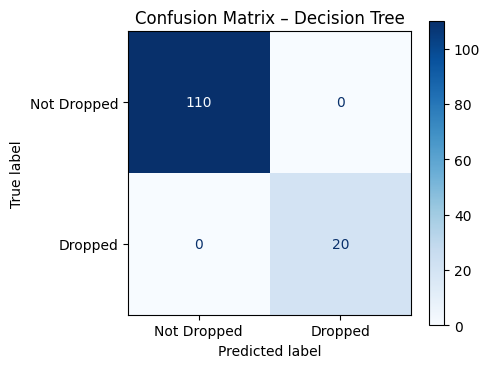

In [48]:
# confusion matrix for best model (by F1) with SMOTE
best_model_name = df_results_smote.iloc[0]['Model']
best_model = models[best_model_name]
best_model.fit(X_train_sm, y_train_sm)
y_pred_best = best_model.predict(X_test)

print(f'Best model: {best_model_name}')
print(classification_report(y_test, y_pred_best, target_names=['Not Dropped', 'Dropped']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Not Dropped', 'Dropped'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix – {best_model_name}', fontsize=12)
plt.tight_layout()
plt.show()

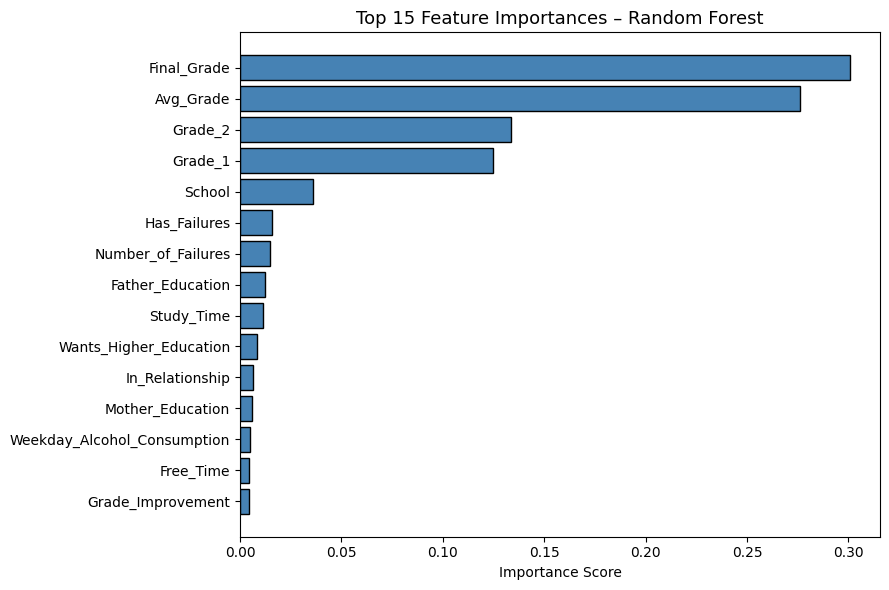

Final_Grade                    0.3006
Avg_Grade                      0.2763
Grade_2                        0.1338
Grade_1                        0.1246
School                         0.0358
Has_Failures                   0.0155
Number_of_Failures             0.0148
Father_Education               0.0122
Study_Time                     0.0114
Wants_Higher_Education         0.0084
In_Relationship                0.0064
Mother_Education               0.0056
Weekday_Alcohol_Consumption    0.0049
Free_Time                      0.0046
Grade_Improvement              0.0045
dtype: float64


In [49]:
# feature importance from Random Forest (good interpretability)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top15 = importances.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15.index[::-1], top15.values[::-1], color='steelblue', edgecolor='black')
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Feature Importances – Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

print(top15.round(4))

In [50]:
# 5-fold cross validation on best model to confirm results are stable
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1  = cross_val_score(best_model, X_scaled, y, cv=skf, scoring='f1')

print(f'5-Fold CV Results for {best_model_name}:')
print(f'  F1-Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

5-Fold CV Results for Decision Tree:
  F1-Score : 1.0000 ± 0.0000


In [51]:
# final summary table of all results with SMOTE
print('=== FINAL RESULTS SUMMARY (With SMOTE) ===')
print(df_results_smote.to_string(index=False))

=== FINAL RESULTS SUMMARY (With SMOTE) ===
              Model  Accuracy  F1-Score  Recall  Precision  G-Mean
      Decision Tree    1.0000    1.0000    1.00     1.0000  1.0000
            XGBoost    1.0000    1.0000    1.00     1.0000  1.0000
  Gradient Boosting    1.0000    1.0000    1.00     1.0000  1.0000
      Random Forest    0.9923    0.9744    0.95     1.0000  0.9747
Logistic Regression    0.9462    0.8372    0.90     0.7826  0.9269
                SVM    0.9154    0.7317    0.75     0.7143  0.8421
        Naive Bayes    0.8615    0.6400    0.80     0.5333  0.8356
K-Nearest Neighbors    0.8077    0.5902    0.90     0.4390  0.8437
